# DriftMind Drift Adaptation Benchmark 

In [1]:
import sys
from pathlib import Path
from pprint import pprint
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from tqdm.auto import tqdm

# Add src/ to path to import driftmind without installing the package
sys.path.insert(0, str(Path.cwd().parent / "benchmarks" / "src"))


# Add src/ to path to import driftmind without installing the package
#sys.path.insert(0, str(Path.cwd().parent / "src"))

from driftmind import DriftMindClient, DriftMindConfigError, DriftMindError
from driftmind.generator import generate_sin_cos_tan_with_drifts, generate_benchmarking_data
from driftmind.utils import (
    load_credentials,
    plot_actual_vs_predicted,
    plot_time_series,
)
from LSTM import LSTMBaseline
from R_ARIMA import RollingARIMABaseline
from S_ARIMA import StaticARIMABaseline
from M_ARIMA import FrozenARIMABaseline
from RR_ARIMA import TriggeredARIMABaseline

c:\Users\Roman\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Ploting Code

In [15]:
def plot_synthetic_benchmark(df, drift_points):
    plt.figure(figsize=(15, 6))
    
    # 1. Plot the raw synthetic signal
    plt.plot(df['sequence'], df['val'], label='Synthetic Signal', color='#1f77b4', alpha=0.8, lw=1)
    
    # 2. Shade the 20% Training Area (Traditional Model Baseline)
    train_end = df[df['is_training'] == True]['sequence'].max()
    plt.axvspan(0, train_end, color='gray', alpha=0.2, label='Traditional Training Zone (20%)')
    
    # 3. Mark the Drift Events with vertical dashed lines
    for i, pt in enumerate(drift_points):
        label = "Drift Events" if i == 0 else None # Avoid duplicate legend entries
        plt.axvline(x=pt, color='red', linestyle='--', alpha=0.7, label=label)
        plt.text(pt, plt.ylim()[1]*0.9, f' D{i+1}', color='red', fontweight='bold')

    # Formatting
    plt.title('Benchmarking Dataset: Concept Drifts & Training Boundary', fontsize=14)
    plt.xlabel('Sequence (Time Step)', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_model_benchmark_old(results_df, drift_points, model_name="Model", color="red"):
    """
    Standardized plotter for benchmarking results.
    Highlights training zone, drifts, and rolling MAE.
    """
    plt.figure(figsize=(15, 6))
    
    # 1. Calculate training boundary
    train_end_idx = results_df[results_df['phase'] == 'train'].index.max()
    training_fraction = (train_end_idx + 1) / len(results_df)

    # 2. Calculate Rolling MAE (ignoring the 0s in training for a cleaner line)
    results_df['rolling_mae'] = results_df['ae'].rolling(window=100).mean()
    
    # 3. Shade the Training Area
    plt.axvspan(0, train_end_idx, color='gray', alpha=0.2, 
                label=f'Training Phase ({int(training_fraction*100)}%)')

    # 4. Plot the Rolling MAE
    plt.plot(results_df.index, results_df['rolling_mae'], 
             label=f'{model_name} Rolling MAE', color=color, lw=2)

    # 5. Mark the Drift Locations
    for i, pt in enumerate(drift_points):
        label = "Drift Events" if i == 0 else None
        plt.axvline(x=pt, color='gray', linestyle='--', alpha=0.5, label=label)
        plt.text(pt, plt.ylim()[1]*0.9, f'D{i+1}', color='black', alpha=0.7, fontweight='bold')

    plt.title(f"{model_name} Performance Decay over Drifts", fontsize=14)
    plt.ylabel("Mean Absolute Error", fontsize=12)
    plt.xlabel("Time Step", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_model_benchmark(results_df, drift_points, break_point, model_name="Model", color="red"):
    plt.figure(figsize=(15, 6))
    
    # 1. Shade Training Zone
    train_end = results_df[results_df['phase'] == 'train'].index.max()
    plt.axvspan(0, train_end, color='gray', alpha=0.15, label='Training Phase')

    # 2. Plot Error
    results_df['rolling_mae'] = results_df['ae'].rolling(window=100).mean()
    plt.plot(results_df.index, results_df['rolling_mae'], label=f'{model_name} MAE', color=color)

    # 3. THE BREAK POINT: Vertical line where MASE > 1.1
    if break_point:
        plt.axvline(x=break_point, color='black', linestyle='-', linewidth=3, 
                    label=f'MODEL BROKEN')
        plt.text(break_point, plt.ylim()[1]*0.7, ' SYSTEM FAILURE\n REQUIRES RETRAIN', 
                 color='black', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    # 4. Drift Events
    for pt in drift_points:
        plt.axvline(x=pt, color='red', linestyle='--', alpha=0.3)

    plt.title(f"{model_name} Benchmark: Performance vs. Fail-Point")
    plt.ylabel("MAE (Rolling Average)")
    plt.xlabel("Time Step")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_prediction_vs_actual(results_df, drift_points):
    """
    Plots a focused window of Actual vs Predicted values.
    """
    # Filter the data for the specific window
   # subset = results_df.iloc[start_idx : start_idx + duration]

  
    
    plt.figure(figsize=(15, 6))
    
    # Plot Actual Signal
    plt.plot(results_df.index, results_df['expected'], label='Actual (Noisy Signal)', 
             color='gray', alpha=0.4, linestyle='--')
    
    # Plot Model Prediction
    plt.plot(results_df.index, results_df['predicted'], label='Model Prediction', 
             color='blue', lw=2)
    
    # Mark any drifts that occur in this window
    for pt in drift_points:
        plt.axvline(x=pt, color='red', linestyle='-', alpha=0.6)

    plt.title(f"Detailed View: Prediction vs Actual")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

    


def plot_smart_benchmark(results_df, drift_points, retrain_point, retrain_reason):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
        
        # 1. Top Plot: MASE & Structural Health
    ax1.plot(results_df.index, results_df['mase'], label='MASE', color='blue')
    ax1.axhline(y=5.0, color='red', linestyle='--', alpha=0.5, label='MASE Limit')
    ax1.set_title("Model Performance (MASE) with Failure Point")
    ax1.set_ylabel("MASE")
        
        # 2. Bottom Plot: Predictions
    ax2.plot(results_df.index, results_df['expected'], color='gray', alpha=0.3, label='Actual')
    ax2.plot(results_df.index, results_df['predicted'], color='blue', label='LSTM Prediction')
    ax2.set_title("Model Predictions vs Actual")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Value")
    ax2.legend(loc='upper right')

        # 3. Add the Failure Marker with the Reason
    if retrain_point is not None:
        reason_text = f" FAILURE: {retrain_reason['type'].replace('_', ' ').upper()}"
            
        for ax in [ax1, ax2]:
            ax.axvline(x=retrain_point, color='black', linewidth=3, label='Retrain Trigger')
            
            # Annotate the specific cause
        ax1.text(retrain_point, ax1.get_ylim()[1]*0.8, reason_text, 
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    # Drift Lines
    for pt in drift_points:
        for ax in [ax1, ax2]:
            ax.axvline(x=pt, color='red', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()



def plot_arima(results_df, drift_points):
    """
    Plots the results of a continuous streaming benchmark, 
    automatically identifying and marking all retraining events.
    """
    # Identify all points where a retrain was triggered
    retrain_events = results_df[results_df['trigger'] != ""]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
        
    # 1. Top Plot: MASE
    ax1.plot(results_df.index, results_df['mase'], label='MASE', color='blue', linewidth=1)
    # Using the limit from your logic (5.0)
    ax1.axhline(y=5.0, color='red', linestyle='--', alpha=0.5, label='MASE Limit')
    ax1.set_title("Model Performance (MASE) & Continuous Retraining Events")
    ax1.set_ylabel("MASE")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')
        
    # 2. Bottom Plot: Predictions
    ax2.plot(results_df.index, results_df['expected'], color='gray',  label='Actual')
    ax2.plot(results_df.index, results_df['predicted'], color='red',alpha=0.4, label='ARIMA Prediction')
    ax2.set_title("Model Predictions vs Actual")
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Value")
    ax2.legend(loc='upper right')

    # 3. Add Vertical Lines for EVERY Retrain Trigger
    for idx, row in retrain_events.iterrows():
        print(f"Retrain triggered at index {idx} due to {row['trigger']}")
        trigger_type = row['trigger'].replace('_', ' ').upper()
        
        for ax in [ax1, ax2]:
            ax.axvline(x=idx, color='black', linewidth=2, linestyle='--', alpha=0.8)
        
        # Annotate the specific cause on the top plot only to avoid clutter
        ax1.annotate(trigger_type, 
                     xy=(idx, ax1.get_ylim()[1]), 
                     xytext=(5, -20), 
                     textcoords='offset points',
                     rotation=90, 
                     fontsize=9,
                     fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 4. Drift Lines (External ground truth drift points if provided)
    for pt in drift_points:
        for ax in [ax1, ax2]:
            ax.axvline(x=pt, color='red', linestyle=':', alpha=0.6, label='Ground Truth Drift' if pt == drift_points[0] else "")
       
    plt.tight_layout()
    plt.show()

### LSTM CODE

In [60]:
def lstm_benchmark_old(df, training_fraction=0.2):
    split_idx = int(len(df) * training_fraction)
    train_data = df['val'].values[:split_idx]
    test_data = df['val'].values[split_idx:]

    current_mase_limit = 10.0
    consecutive_mase_high_limit = 100

    # --- MASE Preparation ---
    # Naive scaling factor: mean absolute error of 'previous value' forecast on training data
    naive_scaling_factor = np.mean(np.abs(np.diff(train_data)))
    
    # Setup and Train
    lstm_bench = LSTMBaseline(seq_length=50)
    lstm_bench.train(train_data)

    lstm_results = []
    # (Training Phase Loop remains the same as your code)
    for actual_val in train_data:
        lstm_results.append({"expected": actual_val, "predicted": 0, "latency": 0, "ae": 0, "phase": "train", "mase": 0})

    current_window = list(train_data[-50:])
    
    # --- Inference with Trigger Logic ---
    recent_aes = []
    break_point_idx = None
    consecutive_mase_high = 0

    print("Executing LSTM Baseline...")
    for i, actual_val in enumerate(tqdm(test_data)):
        pred, latency = lstm_bench.predict_point(current_window)
        ae = abs(actual_val - pred)
        recent_aes.append(ae)
        
        # Monitor MASE over a rolling window of 50 steps
        current_mase = 0
        if len(recent_aes) >= 50:
            window_mae = np.mean(recent_aes[-50:])
            current_mase = window_mae / naive_scaling_factor # Calculate MASE
            
            # Check for  consecutive windows > current_mase_limit
            if break_point_idx is None:
                if current_mase > current_mase_limit:
                    consecutive_mase_high += 1
                else:
                    consecutive_mase_high = 0
                
                if consecutive_mase_high >= consecutive_mase_high_limit:
                    break_point_idx = split_idx + i # Mark the moment of failure

        lstm_results.append({
            "expected": actual_val, "predicted": pred, "latency": latency,
            "ae": ae, "phase": "inference", "mase": current_mase
        })
        
        current_window.pop(0)
        current_window.append(actual_val)

    return pd.DataFrame(lstm_results), break_point_idx


def lstm_benchmark(
    df,
    training_fraction=0.2,
    seq_length=50,
    # --- MASE trigger ---
    mase_limit=5.0,
    mase_consecutive_steps=50,
    # --- Structural triggers (silent collapse) ---
    eval_window=100,
    pred_std_floor_ratio=0.10,   # pred_std must be at least 10% of actual_std
    corr_floor=0.20,             # correlation(pred, actual) must stay above this
    collapse_consecutive_steps=30,
    # --- misc ---
    use_df_index=True
):
    """
    Streaming 1-step-ahead evaluation. Returns:
      - results_df: per-step logs
      - retrain_point: earliest index (or df index) where retraining is recommended
      - retrain_reason: dict describing which trigger fired
    """

    y = df["val"].to_numpy()
    n = len(y)
    split_idx = int(n * training_fraction)

    train_data = y[:split_idx]
    test_data = y[split_idx:]

    if len(train_data) < seq_length + 2:
        raise ValueError(f"Need at least {seq_length+2} training points, got {len(train_data)}.")

    # --- MASE scaling on training (lag-1 naive) ---
    diff = np.diff(train_data)
    naive_scaling_factor = np.nanmean(np.abs(diff))
    if not np.isfinite(naive_scaling_factor) or naive_scaling_factor == 0:
        naive_scaling_factor = 1e-8

    # Train model
    lstm_bench = LSTMBaseline(seq_length=seq_length)
    lstm_bench.train(train_data)

    # Logs
    rows = []

    # Streaming state
    current_window = list(train_data[-seq_length:])

    recent_abs_errors = []
    recent_preds = []
    recent_actuals = []

    # Trigger state
    retrain_at = None
    retrain_reason = None

    mase_bad_run = 0
    collapse_bad_run = 0

    print("Executing LSTM Baseline (streaming)...")
    for i, actual_val in enumerate(tqdm(test_data)):
        global_pos = split_idx + i

        pred, latency = lstm_bench.predict_point(current_window)

        ae = float(abs(actual_val - pred))
        recent_abs_errors.append(ae)

        # windows for structural checks
        recent_preds.append(float(pred))
        recent_actuals.append(float(actual_val))

        # keep windows bounded
        if len(recent_preds) > eval_window:
            recent_preds.pop(0)
            recent_actuals.pop(0)

        # --- compute rolling MASE (on last seq_length errors) ---
        mase = np.nan
        if len(recent_abs_errors) >= seq_length:
            window_mae = float(np.mean(recent_abs_errors[-seq_length:]))
            mase = window_mae / naive_scaling_factor

        # --- structural collapse metrics (needs eval_window points) ---
        pred_std_ratio = np.nan
        corr = np.nan
        if len(recent_preds) >= eval_window:
            p = np.asarray(recent_preds, dtype=float)
            a = np.asarray(recent_actuals, dtype=float)

            p_std = float(np.std(p))
            a_std = float(np.std(a))
            pred_std_ratio = (p_std / a_std) if a_std > 0 else 0.0

            # correlation, safe if std>0
            if p_std > 0 and a_std > 0:
                corr = float(np.corrcoef(p, a)[0, 1])
            else:
                corr = 0.0

        # --- Trigger logic (first firing wins) ---
        if retrain_at is None:
            # 1) MASE-based degradation
            if np.isfinite(mase) and mase > mase_limit:
                mase_bad_run += 1
            else:
                mase_bad_run = 0

            # 2) Collapse-based (flatline / non-responsive predictor)
            collapse_flag = False
            if np.isfinite(pred_std_ratio) and pred_std_ratio < pred_std_floor_ratio:
                collapse_flag = True
            if np.isfinite(corr) and corr < corr_floor:
                collapse_flag = True

            if collapse_flag:
                collapse_bad_run += 1
            else:
                collapse_bad_run = 0

            if collapse_bad_run >= collapse_consecutive_steps:
                retrain_at = global_pos
                retrain_reason = {
                    "type": "structural_collapse",
                    "pred_std_ratio": pred_std_ratio,
                    "corr": corr,
                    "eval_window": eval_window,
                    "collapse_consecutive_steps": collapse_consecutive_steps
                }
            elif mase_bad_run >= mase_consecutive_steps:
                retrain_at = global_pos
                retrain_reason = {
                    "type": "mase_degradation",
                    "mase": mase,
                    "mase_limit": mase_limit,
                    "mase_consecutive_steps": mase_consecutive_steps
                }

        rows.append({
            "pos": global_pos,
            "expected": float(actual_val),
            "predicted": float(pred),
            "latency": float(latency),
            "ae": ae,
            "mase": float(mase) if np.isfinite(mase) else np.nan,
            "pred_std_ratio": float(pred_std_ratio) if np.isfinite(pred_std_ratio) else np.nan,
            "corr": float(corr) if np.isfinite(corr) else np.nan,
            "phase": "inference",
        })

        # streaming update with observed truth
        current_window.pop(0)
        current_window.append(actual_val)

    results_df = pd.DataFrame(rows)

    if retrain_at is None:
        retrain_point = None
    else:
        retrain_point = df.index[retrain_at] if use_df_index else retrain_at

    return results_df, retrain_point, retrain_reason


### Arima Code

In [18]:

def rolling_arima_benchmark_continuous(
    df,
    training_fraction=0.2,
    # ARIMA config
    arima_order=(5, 1, 0),
    arima_fit_window=200,
    # MASE/MAE monitoring
    mase_window=50,
    mase_limit=5.0,
    mase_consecutive_steps=20,
    # Structural collapse monitoring
    eval_window=200,
    pred_std_floor_ratio=0.10,
    corr_floor=0.20,
    collapse_consecutive_steps=50,
    # Failure handling
    nonfinite_consecutive_steps=3,
    # Output
    use_df_index=True
):
    """
    Streaming 1-step-ahead benchmark that retrains the FrozenARIMABaseline 
    whenever performance (MASE) or structural integrity (Correlation/Std) degrades.
    """
    y = df["val"].to_numpy()
    n = len(y)
    split_idx = int(n * training_fraction)

    if split_idx < arima_fit_window:
        print(f"Warning: training_fraction yields {split_idx} samples, "
              f"less than arima_fit_window {arima_fit_window}.")

    # --- Initial Training ---
    history_full = list(y[:split_idx])
    # Train on the most recent slice of the training data
    train_init = y[max(0, split_idx - arima_fit_window):split_idx]
    
    arima = FrozenARIMABaseline(order=arima_order)
    arima.train(train_init)

    # --- Initial Scaling Factor (Naïve 1) ---
    diff = np.diff(train_init)
    naive_scaling_factor = np.nanmean(np.abs(diff))
    if not np.isfinite(naive_scaling_factor) or naive_scaling_factor == 0:
        naive_scaling_factor = 1e-8

    # --- Streaming State ---
    rows = []
    recent_abs_errors = []
    recent_preds = []
    recent_actuals = []
    
    mase_bad_run = 0
    collapse_bad_run = 0
    nonfinite_bad_run = 0
    last_observation = None # Used to update state BEFORE the next prediction

    retrain_count = 0
    
    print(f"Executing Continuous ARIMA Baseline...")

    pbar = tqdm(range(split_idx, n))

    for i in pbar:
        actual_val = y[i]
        global_pos = i

        # 1. Predict next step and update state with the PREVIOUS truth
        # predict_point(new_obs) appends new_obs to the internal state then forecasts
        pred, latency = arima.predict_point(new_obs=last_observation)

        # 2. Hard Failure Check (Non-finite)
        if not np.isfinite(pred):
            nonfinite_bad_run += 1
        else:
            nonfinite_bad_run = 0

        # 3. Metric Accumulation
        ae = float(abs(actual_val - pred)) if np.isfinite(pred) else np.nan
        recent_abs_errors.append(ae)
        recent_preds.append(float(pred) if np.isfinite(pred) else np.nan)
        recent_actuals.append(float(actual_val))

        # Maintain window sizes
        if len(recent_abs_errors) > mase_window:
            recent_abs_errors.pop(0)
        if len(recent_preds) > eval_window:
            recent_preds.pop(0)
            recent_actuals.pop(0)

        # 4. Calculate Rolling Performance
        current_mae = np.nanmean(recent_abs_errors) if recent_abs_errors else np.nan
        mase = current_mae / naive_scaling_factor if current_mae is not np.nan else np.nan

        # Structural metrics
        pred_std_ratio = np.nan
        corr = np.nan
        if len(recent_preds) >= eval_window:
            p = np.array(recent_preds)
            a = np.array(recent_actuals)
            mask = np.isfinite(p)
            if np.sum(mask) >= 10:
                p_std = np.std(p[mask])
                a_std = np.std(a[mask])
                pred_std_ratio = p_std / a_std if a_std > 0 else 0.0
                if p_std > 0 and a_std > 0:
                    corr = np.corrcoef(p[mask], a[mask])[0, 1]

        # 5. Trigger Logic
        trigger = ""
        do_retrain = False

        # Check Non-finite
        if nonfinite_bad_run >= nonfinite_consecutive_steps:
            trigger = "nonfinite_forecast"
            do_retrain = True
        
        # Check MASE
        if not do_retrain:
            if np.isfinite(mase) and mase > mase_limit:
                mase_bad_run += 1
            else:
                mase_bad_run = 0
            
            if mase_bad_run >= mase_consecutive_steps:
                trigger = "mase_degradation"
                do_retrain = True

        # Check Structural Collapse
        if not do_retrain:
            collapse_flag = False
            if np.isfinite(pred_std_ratio) and pred_std_ratio < pred_std_floor_ratio:
                collapse_flag = True
            if np.isfinite(corr) and corr < corr_floor:
                collapse_flag = True
            
            if collapse_flag:
                collapse_bad_run += 1
            else:
                collapse_bad_run = 0
            
            if collapse_bad_run >= collapse_consecutive_steps:
                trigger = "structural_collapse"
                do_retrain = True

        # 6. Execution of Retraining
        if do_retrain:
            retrain_count += 1
            # Get window for retraining
            train_window = y[max(0, i - arima_fit_window):i]
            arima.train(train_window)
            
            # Reset naive scaling based on new regime
            new_diff = np.diff(train_window)
            naive_scaling_factor = np.nanmean(np.abs(new_diff)) or 1e-8
            
            # Reset monitor counters
            mase_bad_run = 0
            collapse_bad_run = 0
            nonfinite_bad_run = 0
            recent_abs_errors = [] # Clear errors so new model starts with fresh MAE
            
            # Critical: last_observation for the NEXT step must be None 
            # because .train() already included data up to index 'i'
            last_observation = None 
        else:
            # Normal streaming: the current truth becomes the 'new_obs' for next step
            last_observation = actual_val
        # This will show [Retrains: X, MASE: Y.YY] next to the bar
        pbar.set_postfix({
            'Retrains': retrain_count,
            'MASE': f"{mase:.2f}" if np.isfinite(mase) else "N/A"
        })
        # 7. Logging
        rows.append({
            "pos": df.index[global_pos] if use_df_index else global_pos,
            "expected": float(actual_val),
            "predicted": float(pred),
            "ae": ae,
            "mae": current_mae,
            "mase": mase,
            "corr": corr,
            "pred_std_ratio": pred_std_ratio,
            "latency": latency,
            "trigger": trigger
        })

    return pd.DataFrame(rows)

In [80]:


def rolling_arima_benchmark_retrain_point(
    df,
    training_fraction=0.2,
    # RollingARIMABaseline config
    arima_order=(5, 1, 0),
    arima_interval=10,
    arima_fit_window=200,

    # MASE monitoring
    mase_window=50,
    mase_limit=5.0,
    mase_consecutive_steps=50,

    # Structural collapse monitoring
    eval_window=200,
    pred_std_floor_ratio=0.10,
    corr_floor=0.20,
    collapse_consecutive_steps=50,

    # ARIMA-specific hard failure
    nonfinite_consecutive_steps=3,

    # Output
    use_df_index=True,
    pad_train_rows=False
):
    """
    Streaming 1-step-ahead benchmark for RollingARIMABaseline.

    Returns:
      results_df: per-step logs with AE, rolling MASE, corr, pred_std_ratio
      retrain_point: earliest point where retraining is recommended (df index if use_df_index)
      retrain_reason: dict describing why the trigger fired
    """
    retrain_at = None
    y = df["val"].to_numpy()
    n = len(y)
    split_idx = int(n * training_fraction)

    train_data = y[:split_idx]
    test_data  = y[split_idx:]

    if len(train_data) < max(3, mase_window + 2):
        raise ValueError("Training segment too short for MASE scaling / ARIMA warm start.")

    # --- MASE scaling factor computed on training (lag-1 naive) ---
    diff = np.diff(train_data)
    naive_scaling_factor = np.nanmean(np.abs(diff))
    if not np.isfinite(naive_scaling_factor) or naive_scaling_factor == 0:
        naive_scaling_factor = 1e-8

    # --- init model ---
    arima = RollingARIMABaseline(order=arima_order, interval=arima_interval)

    # --- logging ---
    rows = []

    if pad_train_rows:
        for v in train_data:
            rows.append({
                "pos": np.nan,
                "expected": float(v),
                "predicted": np.nan,
                "latency": 0.0,
                "ae": np.nan,
                "mase": np.nan,
                "pred_std_ratio": np.nan,
                "corr": np.nan,
                "phase": "train",
                "trigger": ""
            })

    # --- streaming state ---
    history = list(train_data)
    recent_abs_errors = []
    recent_preds = []
    recent_actuals = []

    retrain_at = None
    retrain_reason = None

    mase_bad_run = 0
    collapse_bad_run = 0
    nonfinite_bad_run = 0

    print("Executing Rolling ARIMA Baseline (streaming)...")
    for i, actual_val in enumerate(tqdm(test_data)):
        global_pos = split_idx + i

        # trailing window used for ARIMA apply/refit
        window = history[-arima_fit_window:] if len(history) > arima_fit_window else history

        pred, latency = arima.predict_point(window)

        # --- ARIMA hard failure: non-finite forecast ---
        if not np.isfinite(pred):
            nonfinite_bad_run += 1
        else:
            nonfinite_bad_run = 0

        # compute AE even if pred is non-finite (will become inf/nan)
        ae = float(abs(actual_val - pred)) if np.isfinite(pred) else np.nan
        recent_abs_errors.append(ae)

        recent_preds.append(float(pred) if np.isfinite(pred) else np.nan)
        recent_actuals.append(float(actual_val))

        # bound windows
        if len(recent_preds) > eval_window:
            recent_preds.pop(0)
            recent_actuals.pop(0)

        # --- Rolling MASE ---
        mase = np.nan
        if len(recent_abs_errors) >= mase_window:
            tail = np.asarray(recent_abs_errors[-mase_window:], dtype=float)
            if np.all(np.isfinite(tail)):
                window_mae = float(np.mean(tail))
                mase = window_mae / naive_scaling_factor

        # --- Structural metrics (ignore NaNs in preds) ---
        pred_std_ratio = np.nan
        corr = np.nan
        if len(recent_preds) >= eval_window:
            p = np.asarray(recent_preds, dtype=float)
            a = np.asarray(recent_actuals, dtype=float)
            mask = np.isfinite(p) & np.isfinite(a)

            if np.sum(mask) >= max(10, eval_window // 3):
                p2, a2 = p[mask], a[mask]
                p_std = float(np.std(p2))
                a_std = float(np.std(a2))
                pred_std_ratio = (p_std / a_std) if a_std > 0 else 0.0

                if p_std > 0 and a_std > 0:
                    corr = float(np.corrcoef(p2, a2)[0, 1])
                else:
                    corr = 0.0

        # --- Trigger logic ---
        trigger = ""
        if retrain_at is None:
            # 0) hard failure
            if nonfinite_bad_run >= nonfinite_consecutive_steps:
                retrain_at = global_pos
                retrain_reason = {
                    "type": "nonfinite_forecast",
                    "nonfinite_consecutive_steps": nonfinite_consecutive_steps
                }
                trigger = "nonfinite_forecast"

            # 1) MASE degradation
            if retrain_at is None:
                if np.isfinite(mase) and mase > mase_limit:
                    mase_bad_run += 1
                else:
                    mase_bad_run = 0

                if mase_bad_run >= mase_consecutive_steps:
                    retrain_at = global_pos
                    retrain_reason = {
                        "type": "mase_degradation",
                        "mase": mase,
                        "mase_limit": mase_limit,
                        "mase_consecutive_steps": mase_consecutive_steps,
                        "mase_window": mase_window
                    }
                    trigger = "mase_degradation"

            # 2) structural collapse (secondary)
            if retrain_at is None:
                collapse_flag = False
                if np.isfinite(pred_std_ratio) and pred_std_ratio < pred_std_floor_ratio:
                    collapse_flag = True
                if np.isfinite(corr) and corr < corr_floor:
                    collapse_flag = True

                if collapse_flag:
                    collapse_bad_run += 1
                else:
                    collapse_bad_run = 0

                if collapse_bad_run >= collapse_consecutive_steps:
                    retrain_at = global_pos
                    retrain_reason = {
                        "type": "structural_collapse",
                        "pred_std_ratio": pred_std_ratio,
                        "corr": corr,
                        "eval_window": eval_window,
                        "collapse_consecutive_steps": collapse_consecutive_steps
                    }
                    trigger = "structural_collapse"

        rows.append({
            "pos": global_pos,
            "expected": float(actual_val),
            "predicted": float(pred) if np.isfinite(pred) else np.nan,
            "latency": float(latency),
            "ae": ae,
            "mase": float(mase) if np.isfinite(mase) else np.nan,
            "pred_std_ratio": float(pred_std_ratio) if np.isfinite(pred_std_ratio) else np.nan,
            "corr": float(corr) if np.isfinite(corr) else np.nan,
            "phase": "inference",
            "trigger": trigger
        })

        # streaming update with observed truth
        history.append(actual_val)

    results_df = pd.DataFrame(rows)

    retrain_point = None
    if retrain_at is not None:
        retrain_point = df.index[retrain_at] if use_df_index else retrain_at

    return results_df, retrain_point, retrain_reason




def rolling_arima_benchmark(df,training_fraction=0.2):
    split_idx = int(len(df) * training_fraction)
    train_data = df['val'].values[:split_idx]
    test_data = df['val'].values[split_idx:]

    arima_bench = RollingARIMABaseline(order=(5, 1, 0))
    arima_results = []

    # Pad the training phase to match your LSTM plot structure
    for i in range(split_idx):
        arima_results.append({
            "expected": train_data[i],
            "predicted": 0,
            "latency": 0,
            "ae": 0,
            "phase": "train"
        })

    # Initialize history with the training data
    history = list(train_data)

    print("Executing ARIMA Rolling Baseline (This will be SLOWER than LSTM)...")
    # For speed during testing, you might want to slice test_data[:1000] first
    for actual_val in tqdm(test_data):
        # We only pass the last 200 points to keep the fit time reasonable
        current_window = history[-200:] 
        pred, latency = arima_bench.predict_point(current_window)
        
        arima_results.append({
            "expected": actual_val,
            "predicted": pred,
            "latency": latency,
            "ae": abs(actual_val - pred),
            "phase": "inference"
        })
        # Check for  consecutive windows > current_mase_limit
        if break_point_idx is None:
            if current_mase > current_mase_limit:
                consecutive_mase_high += 1
            else:
                consecutive_mase_high = 0
                
            if consecutive_mase_high >= consecutive_mase_high_limit:
                break_point_idx = split_idx + i # Mark the moment of failure

        
        history.append(actual_val)

    # 4. Assessment
    res_df = pd.DataFrame(arima_results)
    inf_df = res_df[res_df['phase'] == 'inference']
    
    print(f"\nRolling ARIMA - MAE: {inf_df['ae'].mean():.4f}, Latency: {inf_df['latency'].mean()*1000:.4f}ms")

    return pd.DataFrame(arima_results)

def classic_arima_benchmark(df, training_fraction=0.2):
    split_idx = int(len(df) * training_fraction)
    train_data = df['val'].values[:split_idx]
    test_data = df['val'].values[split_idx:]

    # 1. Initialize and Train once
    arima_static = StaticARIMABaseline(order=(5, 1, 0))
    print(f"Training Static ARIMA on first {split_idx} points...")
    arima_static.train(train_data)

    results = []

    # 2. Pad Training Phase for visualization
    for i in range(split_idx):
        results.append({
            "expected": train_data[i],
            "predicted": 0,
            "latency": 0,
            "ae": 0,
            "phase": "train"
        })

    # 3. Inference Loop
    history = list(train_data)
    print("Executing Static ARIMA Inference...")
    for actual_val in tqdm(test_data):
        # Using 50-point lookback for consistency with LSTM
        current_window = history[-50:] 
        
        pred, latency = arima_static.predict_point(current_window)
        
        results.append({
            "expected": actual_val,
            "predicted": pred,
            "latency": latency,
            "ae": abs(actual_val - pred),
            "phase": "inference"
        })
        history.append(actual_val)

    # 4. Assessment
    res_df = pd.DataFrame(results)
    inf_df = res_df[res_df['phase'] == 'inference']
    
    print(f"\nStatic ARIMA - MAE: {inf_df['ae'].mean():.4f}, Latency: {inf_df['latency'].mean()*1000:.4f}ms")
    
    return res_df


## 3. Generate synthetic dataset with drifts

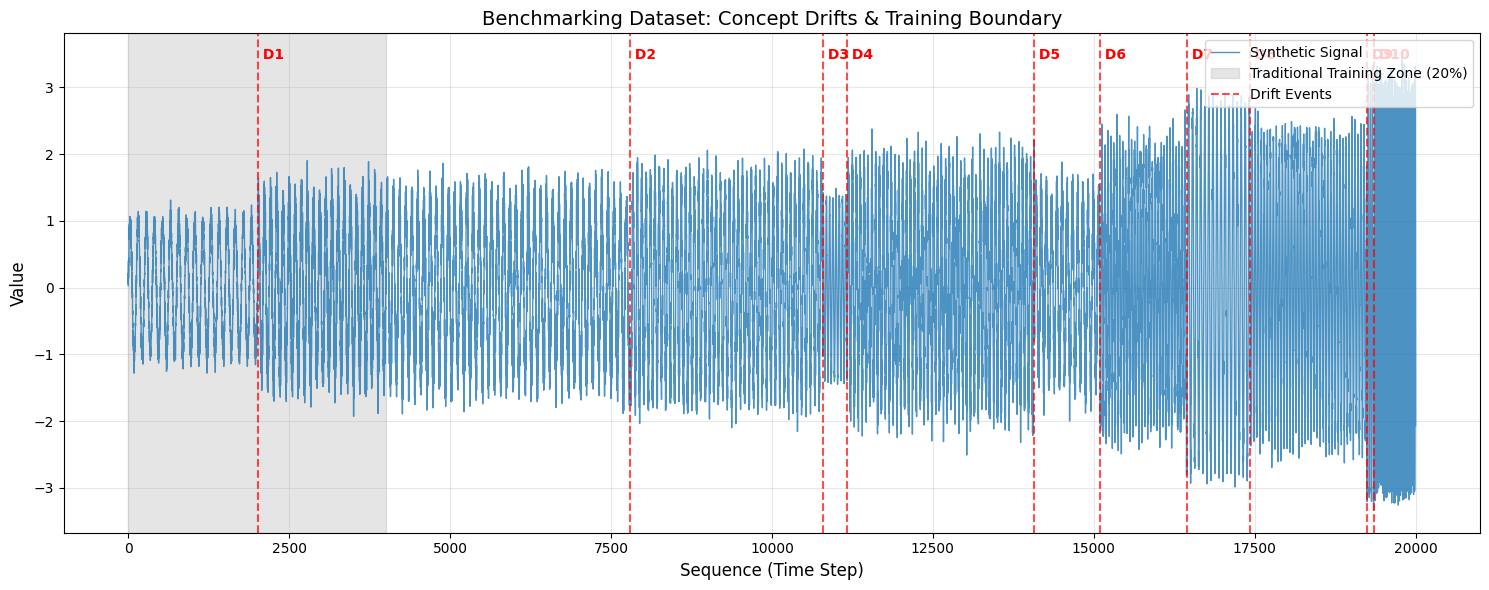

In [5]:
#df_large, drift_locs = generate_benchmarking_data(n_points=20000, n_drifts=10)

plot_synthetic_benchmark(df_large, drift_locs)

## 1. TESTING LSTM 

In [21]:
training_fraction=0.2
lstm_df, break_point_idx, retrain_reason = lstm_benchmark(df_large, training_fraction)
plot_smart_benchmark(lstm_df, drift_locs, break_point_idx, retrain_reason)

NameError: name 'lstm_benchmark' is not defined

## Test Rolling Arima

Executing Continuous ARIMA Baseline...


100%|██████████| 16000/16000 [23:59<00:00, 11.11it/s, Retrains=1, MASE=2.45]


Retrain triggered at index 15382 due to mase_degradation


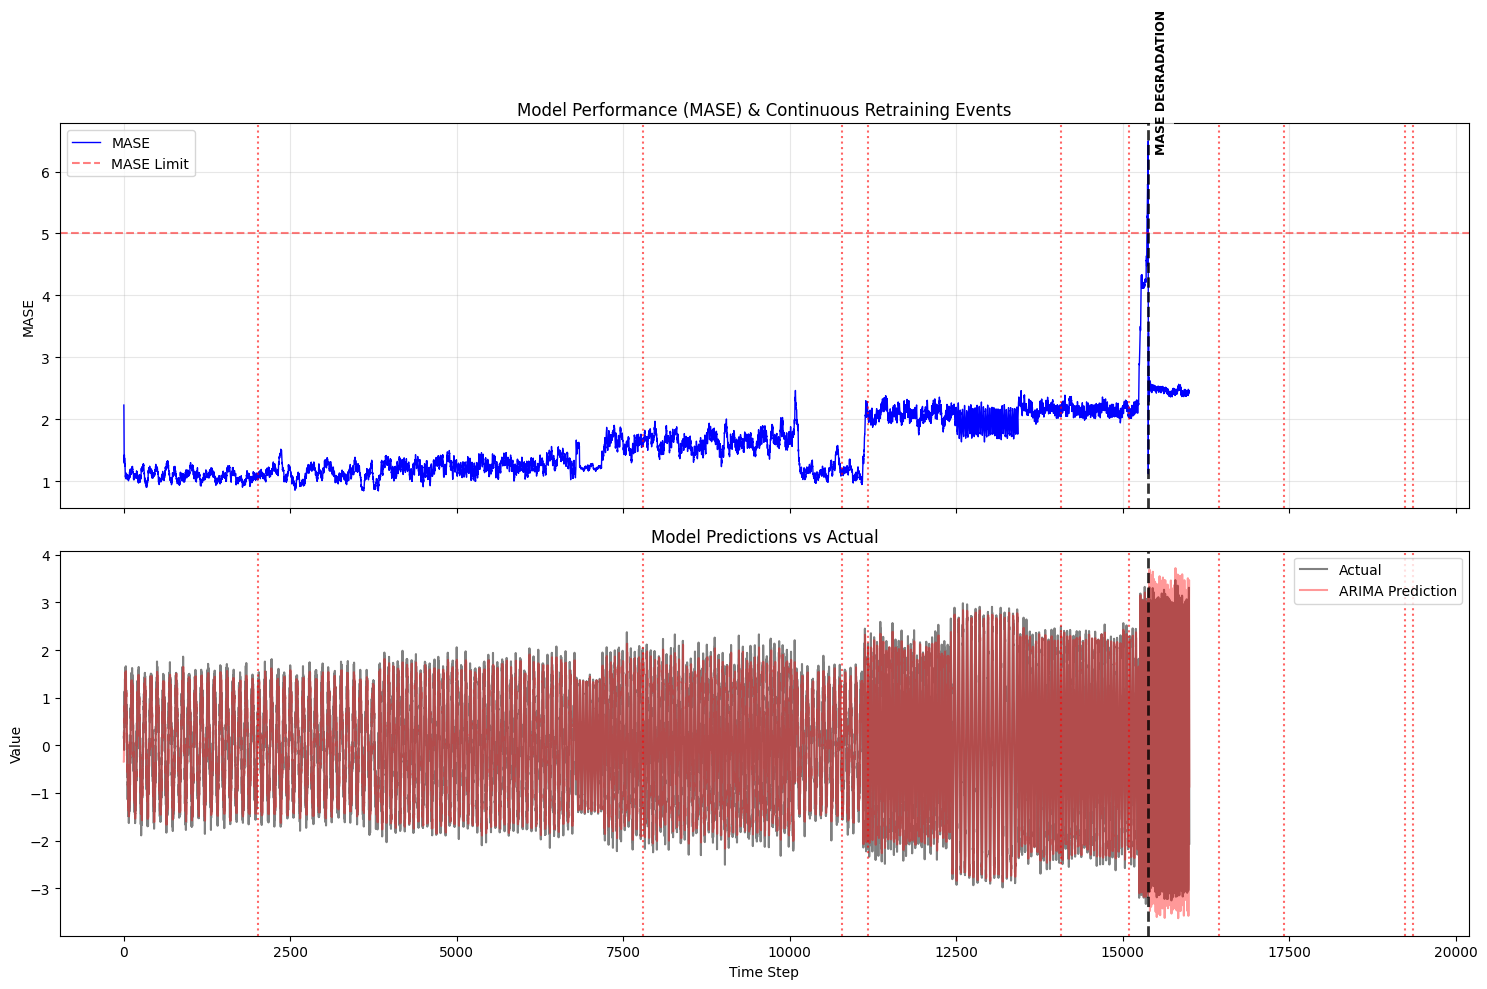

In [22]:
arima_rolling_df = rolling_arima_benchmark_continuous(df_large)
plot_arima(arima_rolling_df, drift_locs)

## 1. Load DriftMind credentials from a '.env' file

Credentials are expected as:

- `DRIFTMIND_API_KEY`
- `DRIFTMIND_API_URL`

In [3]:
try:
    env_path = Path("..") / "env" / ".env"
    creds = load_credentials(str(env_path))
    api_key = creds["DRIFTMIND_API_KEY"]
    base_url = creds["DRIFTMIND_API_URL"]
    print("✅ Credentials loaded. Target URL:", base_url)
except DriftMindConfigError as err:
    raise RuntimeError(
        "Failed to load DriftMind credentials. "
        "Ensure DRIFTMIND_API_KEY and DRIFTMIND_API_URL are set in "
        "your environment or .env file."
    ) from err

client = DriftMindClient(api_key=api_key, base_url=base_url)


✅ Credentials loaded. Target URL: https://api.thingbook.io/access/api/driftmind/v1/


## 2. Create a new forecaster

We create a fresh forecaster for this demo run.

In [7]:
columns = ["sin", "cos", "tan"]

forecaster_payload = {
    "forecasterName": "Cold Start Demo",
    "features": columns,
    "inputSize": 25,
    "outputSize": 1,
    "maxClustersAllowed": 100,
    "timeStampIntervalInSeconds": 30,
}

try:
    forecaster_info = client.create_forecaster(forecaster_payload)
except DriftMindError as err:
    raise RuntimeError("Failed to create forecaster.") from err

for key in ("forecaster_id", "forecasterId", "id"):
    if forecaster_id := forecaster_info.get(key):
        break
else:
    raise RuntimeError("Could not determine forecaster ID from response.")

print(f"Created new forecaster with ID: {forecaster_id}")

show_forecaster_details(client, forecaster_id)

Created new forecaster with ID: 8cdbf0b0-546f-4850-813a-8d08faa87d30


### Forecaster Details

,Value
ID,8cdbf0b0-546f-4850-813a-8d08faa87d30
Name,Cold Start Demo
Features,"tan, sin, cos"


**Configuration:**

,Value
fitRate,1
initializationDate,13-02-2026 10:56:53
maxClustersAllowed,100
dateFormat,dd-MM-yyyy HH:mm:ss
similarityThreshold,0.8
timeStampIntervalInSeconds,30
outputSize,1
inputSize,25


## 4. Online loop: feed points and request forecasts

We iterate over the dataset, feed one point at a time, and request a forecast. We collect:

- Per-feature expected vs predicted values.
- Global anomaly score and number of clusters.

In [23]:
results = {col: [] for col in columns}
errors = {col: [] for col in columns}
metrics_evolution = {col: [] for col in columns}

global_results = {"timestamp": [], "anomaly_score": [], "number_of_clusters": []}

total_points = len(df)
print(f"Starting online learning and forecasting for {total_points} points...")

for _, row in df.iterrows():
    point = {col: [float(row[col])] for col in columns}

    try:
        client.feed_point(forecaster_id, point)
        yhat = client.forecast(forecaster_id)
    except DriftMindError as err:
        print(f"❌ Error: {err}")
        continue

    if yhat is None:
        continue

    seq = int(row["sequence"])
    print(f"Data Returned: {yhat}") # Matches your screenshot

    global_results["timestamp"].append(seq)
    global_results["anomaly_score"].append(float(yhat.get("anomalyScore", 0.0)))
    global_results["number_of_clusters"].append(int(yhat.get("numberOfClusters", 0)))

    features_map = yhat.get("FeaturesMap", {}) or yhat.get("features", {})

    percent_complete = ((seq + 1) / total_points) * 100

    for var in columns:
        feature = features_map.get(var, {})
        preds = feature.get("predictions", [])
        if not preds:
            continue

        pred_val = float(preds[0])
        exp_val = float(row[var])

        # Store results
        results[var].append({"expected": exp_val, "predicted": pred_val, "timestamp": seq})

        # Logic that works (from your screenshot)
        err = exp_val - pred_val
        errors[var].append(err)

        ae = abs(err)
        mae = sum(abs(e) for e in errors[var]) / len(errors[var])
        mse = sum(e * e for e in errors[var]) / len(errors[var])
        rmse = mse ** 0.5

        # Only addition: Save history for plotting
        metrics_evolution[var].append({"timestamp": seq, "MAE": mae, "RMSE": rmse})

        print(
            f"[{percent_complete:.1f}%] Fed sequence={seq}, Expected {var}={exp_val:.3f}, "
            f"Predicted {pred_val:.3f}, AE={ae:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}"
        )

# Summary logic exactly as per your screenshot
print("\n=== Final Forecast Error Summary ===")
for var in columns:
    if not errors[var]: continue
    mae = sum(abs(e) for e in errors[var]) / len(errors[var])
    rmse = (sum(e * e for e in errors[var]) / len(errors[var])) ** 0.5
    print(f"{var}: MAE={mae:.4f}, RMSE={rmse:.4f} (n={len(errors[var])})")

Starting online learning and forecasting for 600 points...
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
❌ Error: [422] FORECAST_NOT_READY
Data Returned:
{'anomalyScore': 0.02, 'numberOfClusters': 3, 'features': {'tan': {'timestam

## 5. Visualize actual vs predicted

We convert the collected results into DataFrames and use the plotting
helpers from `driftmind.utils`.

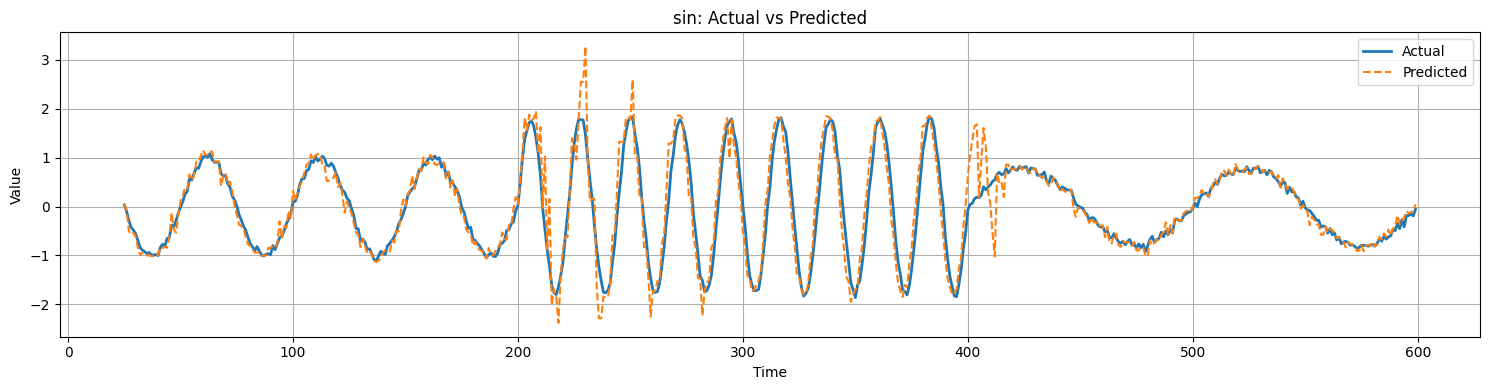

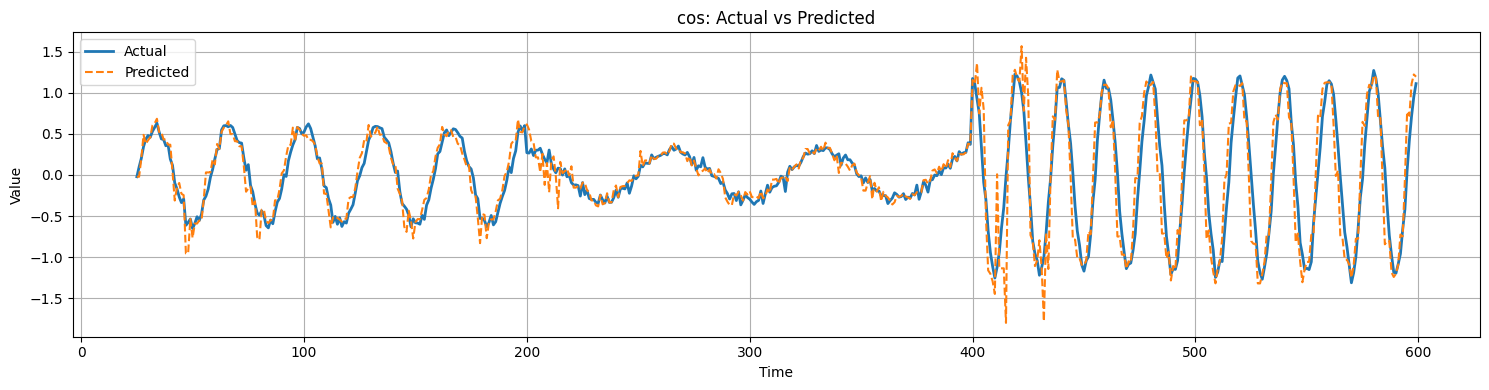

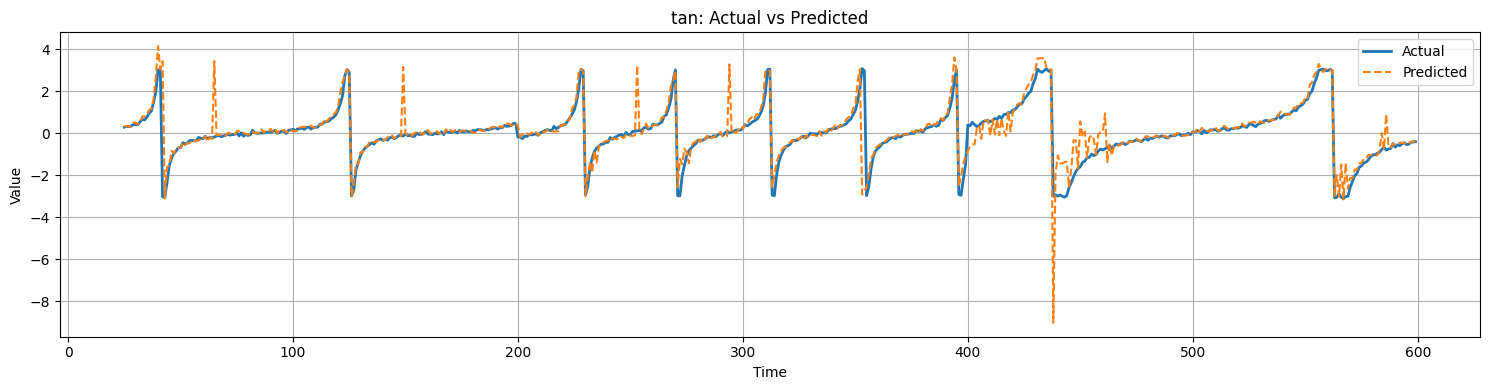

In [24]:
for var in columns:
    df_var = pd.DataFrame(results[var])
    if df_var.empty:
        print(f"No prediction data collected for {var}.")
        continue
    plot_actual_vs_predicted(df_var, variable_name=var)

## 6. Visualize global anomaly score and number of clusters

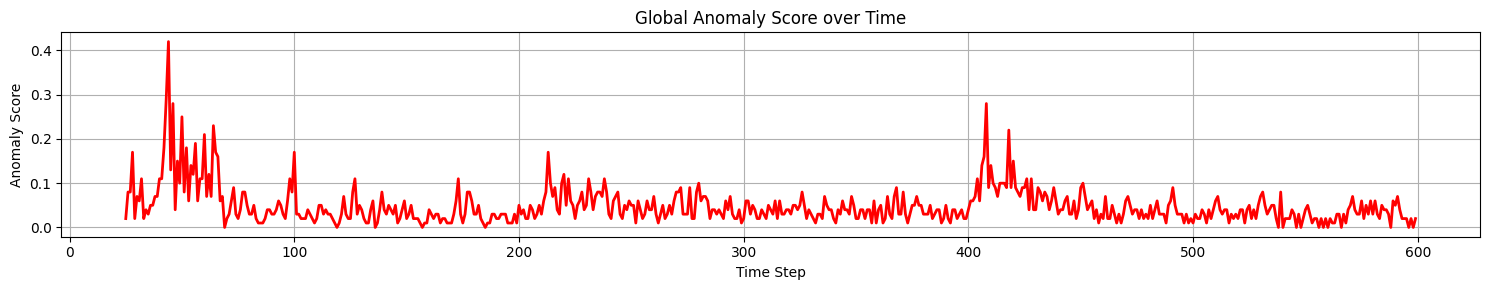

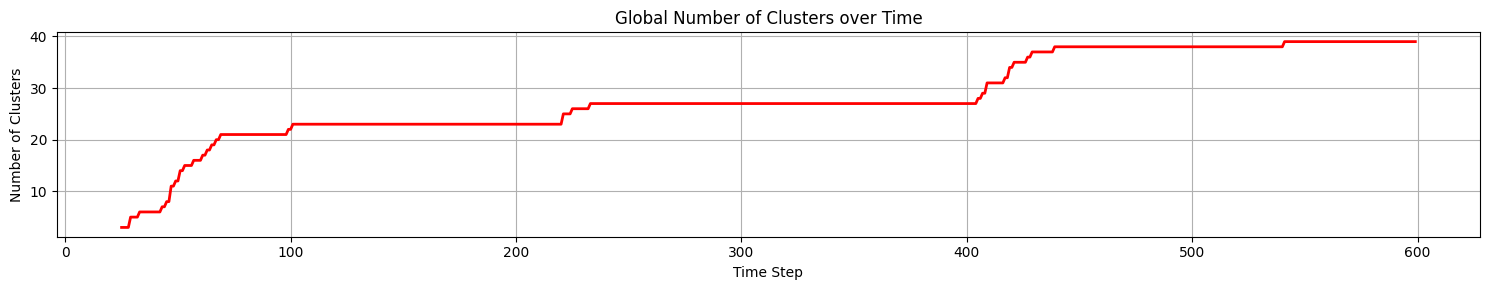

In [25]:
df_global = pd.DataFrame(global_results)

if df_global.empty:
    print("No global metrics collected.")
else:
    plot_time_series(
        df_global["timestamp"],
        df_global["anomaly_score"],
        title="Global Anomaly Score over Time",
        xlabel="Time Step",
        ylabel="Anomaly Score",
    )

    plot_time_series(
        df_global["timestamp"],
        df_global["number_of_clusters"],
        title="Global Number of Clusters over Time",
        xlabel="Time Step",
        ylabel="Number of Clusters",
    )

## 7. Visualize forecast error metrics evolution

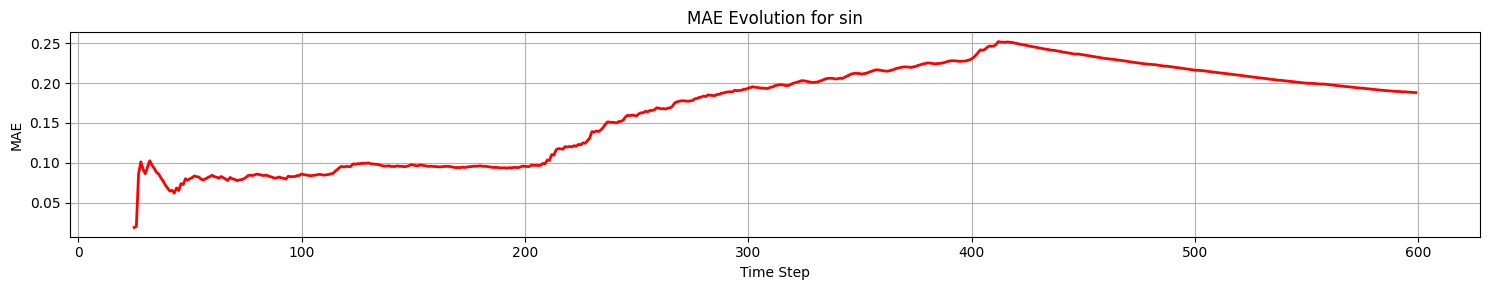

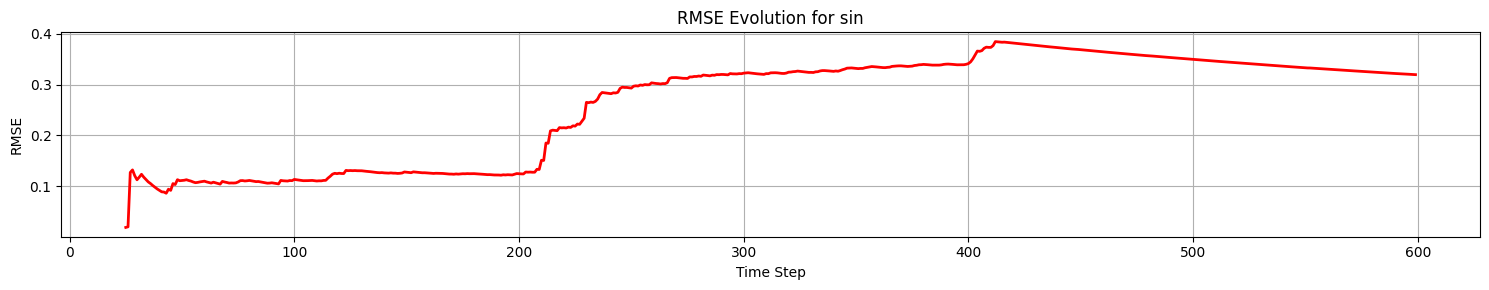

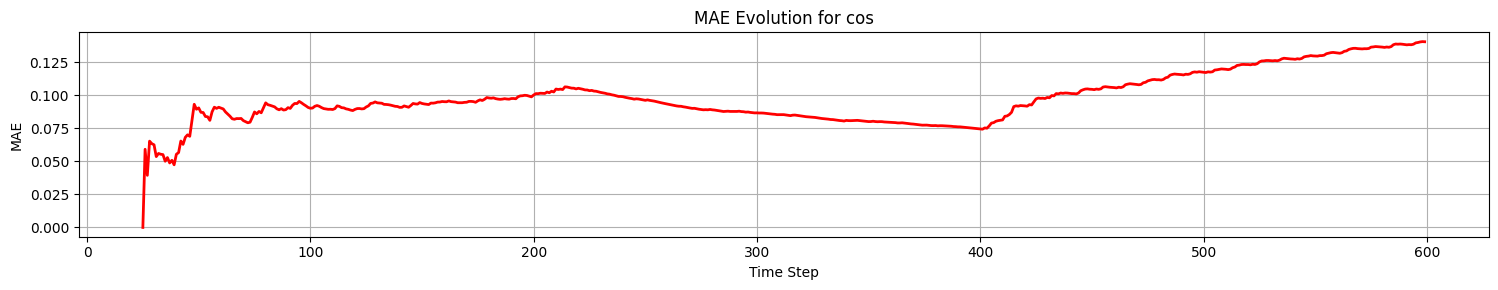

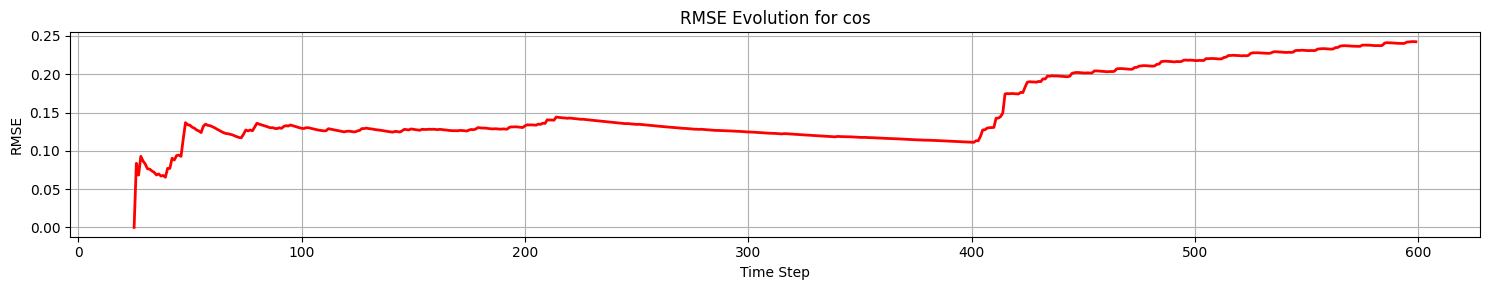

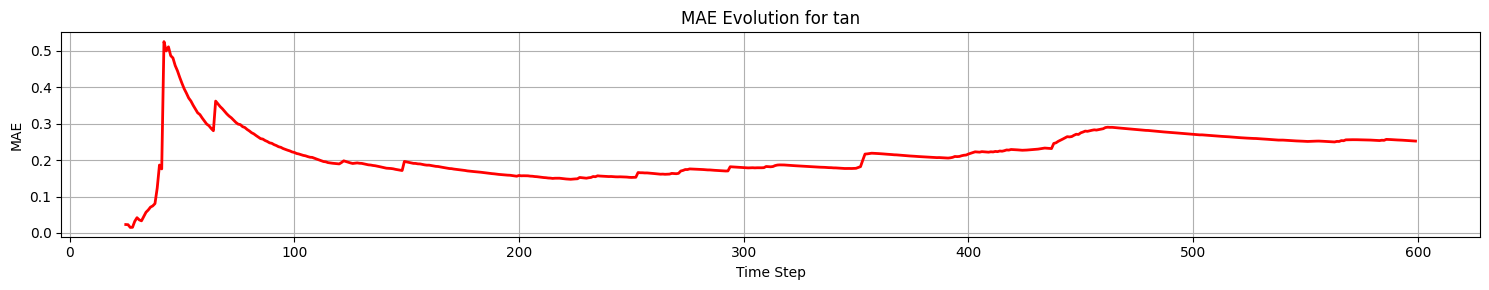

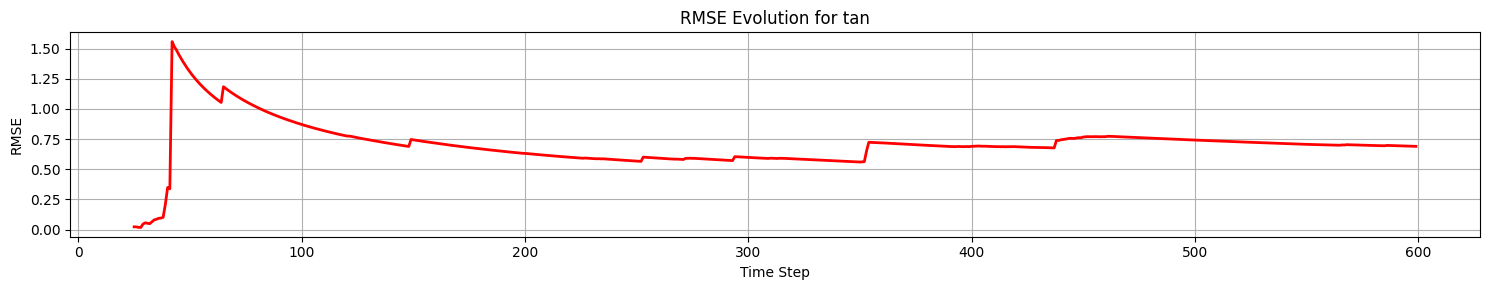

In [26]:
for var in columns:
    df_metrics = pd.DataFrame(metrics_evolution[var])
    if df_metrics.empty:
        continue

    plot_time_series(
        df_metrics["timestamp"],
        df_metrics["MAE"],
        title=f"MAE Evolution for {var}",
        xlabel="Time Step",
        ylabel="MAE",
    )

    plot_time_series(
        df_metrics["timestamp"],
        df_metrics["RMSE"],
        title=f"RMSE Evolution for {var}",
        xlabel="Time Step",
        ylabel="RMSE",
    )

## 8. Inspect forecaster data stored on the server

In [27]:
show_forecaster_data(client, forecaster_id)

### Forecaster Data (26 points)

**First 10 points:**

13-02-2026 15:20:58 → tan=-1.6251, sin=-0.8316, cos=-0.2747
13-02-2026 15:21:28 → tan=-1.5653, sin=-0.7951, cos=-0.047
13-02-2026 15:21:58 → tan=-1.4212, sin=-0.7948, cos=0.3727
13-02-2026 15:22:28 → tan=-1.3828, sin=-0.7952, cos=0.6946
13-02-2026 15:22:58 → tan=-1.2863, sin=-0.8117, cos=1.0166
13-02-2026 15:23:28 → tan=-1.1302, sin=-0.7843, cos=1.1003
13-02-2026 15:23:58 → tan=-1.0372, sin=-0.7803, cos=1.2739
13-02-2026 15:24:28 → tan=-1.0355, sin=-0.8094, cos=1.1748
13-02-2026 15:24:58 → tan=-0.9618, sin=-0.7527, cos=0.9865
13-02-2026 15:25:28 → tan=-0.914, sin=-0.6564, cos=0.6666


*... 6 points omitted ...*

**Last 10 points:**

13-02-2026 15:28:58 → tan=-0.6692, sin=-0.4928, cos=-1.1964
13-02-2026 15:29:28 → tan=-0.5595, sin=-0.3434, cos=-1.0853
13-02-2026 15:29:58 → tan=-0.6021, sin=-0.4527, cos=-0.9603
13-02-2026 15:30:28 → tan=-0.5144, sin=-0.2675, cos=-0.6649
13-02-2026 15:30:58 → tan=-0.4594, sin=-0.4163, cos=-0.42
13-02-2026 15:31:28 → tan=-0.5491, sin=-0.1866, cos=0.0555
13-02-2026 15:31:58 → tan=-0.5293, sin=-0.1839, cos=0.4216
13-02-2026 15:32:28 → tan=-0.4394, sin=-0.1503, cos=0.719
13-02-2026 15:32:58 → tan=-0.4195, sin=-0.1929, cos=0.9545
13-02-2026 15:33:28 → tan=-0.405, sin=-0.0576, cos=1.1131


## 9. List all the forecasters stored in the Server

In [28]:
import json 

all_forecasters = client.list_forecasters()

print(json.dumps(all_forecasters, indent=2))

[
  {
    "object_id": "1a5ac553-dfce-4019-b830-b2d5f5f210d6",
    "object_name": "Cold Start Demo",
    "created_at": "2026-02-13",
    "created_by": "8JBKROTrZ9CYSxFQ3e_e5uWhEOySOjkyMD0IzMDE3MTMwNjUwNTI4NzVcxNzU0NzMxMTM0ODY4Mjk2MjUw",
    "object_type": "FORECASTER",
    "data_processed": -0.01,
    "requests_processed": 2
  },
  {
    "object_id": "4017ae3b-6535-47ad-87c2-bf4fd1f7f251",
    "object_name": "Cold Start Demo",
    "created_at": "2026-02-13",
    "created_by": "8JBKROTrZ9CYSxFQ3e_e5uWhEOySOjkyMD0IzMDE3MTMwNjUwNTI4NzVcxNzU0NzMxMTM0ODY4Mjk2MjUw",
    "object_type": "FORECASTER",
    "data_processed": -0.42,
    "requests_processed": 1177
  },
  {
    "object_id": "21831c29-715f-4ebb-b8ba-863c8c6ce939",
    "object_name": "Cold Start Demo",
    "created_at": "2026-02-13",
    "created_by": "8JBKROTrZ9CYSxFQ3e_e5uWhEOySOjkyMD0IzMDE3MTMwNjUwNTI4NzVcxNzU0NzMxMTM0ODY4Mjk2MjUw",
    "object_type": "FORECASTER",
    "data_processed": -1.67,
    "requests_processed": 4777
  },
  

## 10. Delete the Forecaster Model

In [8]:
print(f"Cleaning up forecaster {forecaster_id}...")

try:
    success = client.delete_forecaster(forecaster_id)
    if success:
        print(f"✅ Successfully deleted forecaster: {forecaster_id}")
except DriftMindError as err:
    # We use a warning here instead of raising so the session can still close
    print(f"⚠️ Failed to delete forecaster {forecaster_id}: {err}")




Cleaning up forecaster 8cdbf0b0-546f-4850-813a-8d08faa87d30...
✅ Successfully deleted forecaster: 8cdbf0b0-546f-4850-813a-8d08faa87d30


## 11. Close the Session

In [11]:
client.close()
print("Session closed.")

Session closed.
